# Demographics Deep Dive
**Notebook 03**

This notebook goes beyond the EDA overview to provide granular demographic analysis:
- **Statistical profiling** — Distributions, normality tests, and outlier detection
- **Mortality modeling** — Survival curves, risk factors, logistic regression
- **Disparity analysis** — Race, ethnicity, and gender-based health equity metrics
- **Geographic clustering** — County-level concentration, rural vs urban patterns
- **Cohort comparisons** — High-cost vs low-cost patients, chronic vs healthy demographics
- **Power BI-ready exports** — Summary tables saved to `data/processed/`


## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'
COLORS = sns.color_palette('muted', 10)
HIGHLIGHT = '#e74c3c'

import os
for p in ['.', '..', '../..']:
    if os.path.exists(os.path.join(p, 'data/raw/patients.csv')):
        os.chdir(p); break

patients      = pd.read_csv('data/raw/patients.csv')
encounters    = pd.read_csv('data/raw/encounters.csv')
conditions    = pd.read_csv('data/raw/conditions.csv')
medications   = pd.read_csv('data/raw/medications.csv')
observations  = pd.read_csv('data/raw/observations.csv')
payers        = pd.read_csv('data/raw/payers.csv')

patients['BIRTHDATE']  = pd.to_datetime(patients['BIRTHDATE'])
patients['DEATHDATE']  = pd.to_datetime(patients['DEATHDATE'])
encounters['START']    = pd.to_datetime(encounters['START'], utc=True)
encounters['STOP']     = pd.to_datetime(encounters['STOP'], utc=True)
conditions['START']    = pd.to_datetime(conditions['START'])

ref_date = pd.Timestamp('2020-04-01')
patients['AGE'] = patients.apply(
    lambda r: (r['DEATHDATE'] - r['BIRTHDATE']).days / 365.25
              if pd.notna(r['DEATHDATE'])
              else (ref_date - r['BIRTHDATE']).days / 365.25, axis=1).astype(int)
patients['IS_ALIVE'] = patients['DEATHDATE'].isna()
patients['AGE_GROUP'] = pd.cut(patients['AGE'],
    bins=[0, 18, 35, 50, 65, 80, 120],
    labels=['0-17', '18-34', '35-49', '50-64', '65-79', '80+'])

os.makedirs('data/processed', exist_ok=True)
print(f"Loaded {len(patients):,} patients")


Loaded 1,171 patients


---
## 1. Statistical Profiling
Descriptive statistics, distribution shape tests, and outlier identification for key continuous variables.


In [2]:
# 1.1 Comprehensive descriptive statistics
num_cols = ['AGE', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE']
desc = patients[num_cols].describe(percentiles=[.05, .25, .5, .75, .95]).T
desc['IQR'] = desc['75%'] - desc['25%']
desc['skewness'] = patients[num_cols].skew()
desc['kurtosis'] = patients[num_cols].kurtosis()
print("=== Descriptive Statistics ===")
print(desc.round(2).to_string())

# Normality tests
print("\n=== Shapiro-Wilk Normality Test ===")
for col in num_cols:
    sample = patients[col].dropna().sample(min(500, len(patients)), random_state=42)
    stat, p = stats.shapiro(sample)
    print(f"  {col:<25} W={stat:.4f}  p={p:.2e}  {'Normal' if p > 0.05 else 'Non-normal'}")


=== Descriptive Statistics ===
                      count       mean        std      min        5%        25%       50%         75%         95%         max         IQR  skewness  kurtosis
AGE                  1171.0      41.07      24.34     0.00      3.00      21.00      41.0       60.00       81.00      110.00       39.00      0.22     -0.72
HEALTHCARE_EXPENSES  1171.0  764940.90  546474.87  1822.16  25701.59  233551.56  718679.1  1260843.74  1610405.28  2145924.40  1027292.18      0.16     -1.32
HEALTHCARE_COVERAGE  1171.0   12932.74   43882.48     0.00    645.80    3101.02    5741.8    10569.08    31850.46   927873.53     7468.05     12.85    211.86

=== Shapiro-Wilk Normality Test ===
  AGE                       W=0.9783  p=8.66e-07  Non-normal
  HEALTHCARE_EXPENSES       W=0.9416  p=4.13e-13  Non-normal
  HEALTHCARE_COVERAGE       W=0.1612  p=3.28e-42  Non-normal


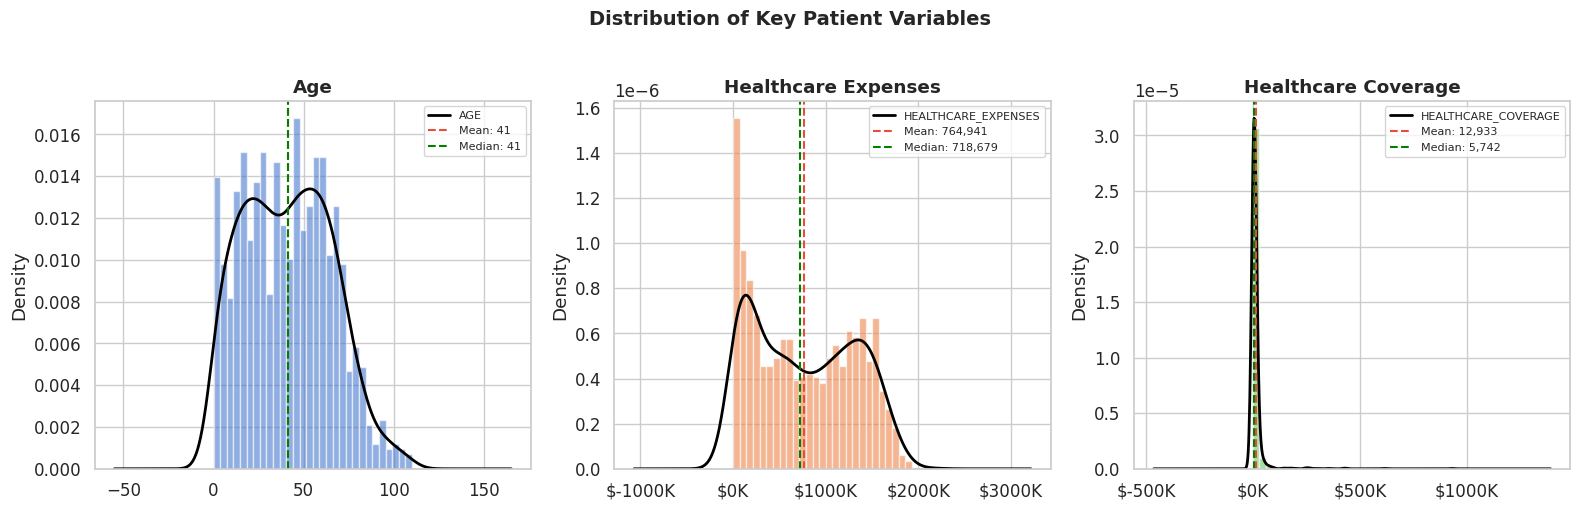

In [3]:
# 1.2 Distribution plots with KDE overlay
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = patients[col].dropna()
    ax.hist(data, bins=30, density=True, alpha=0.6, color=COLORS[i], edgecolor='white')
    data.plot.kde(ax=ax, color='black', linewidth=2)
    ax.axvline(data.mean(), color=HIGHLIGHT, linestyle='--', label=f'Mean: {data.mean():,.0f}')
    ax.axvline(data.median(), color='green', linestyle='--', label=f'Median: {data.median():,.0f}')
    ax.set_title(col.replace('_', ' ').title())
    ax.legend(fontsize=8)
    if 'EXPENSE' in col or 'COVERAGE' in col:
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.suptitle('Distribution of Key Patient Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/28_demographic_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


In [4]:
# 1.3 Outlier detection using IQR method
print("=== Outlier Detection (IQR Method) ===")
outlier_summary = []
for col in ['AGE', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE']:
    Q1 = patients[col].quantile(0.25)
    Q3 = patients[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = patients[(patients[col] < lower) | (patients[col] > upper)]
    outlier_summary.append({
        'Variable': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower_Bound': lower, 'Upper_Bound': upper,
        'Outlier_Count': len(outliers), 'Outlier_Pct': len(outliers)/len(patients)*100
    })
    print(f"  {col:<25} Outliers: {len(outliers):>4} ({len(outliers)/len(patients)*100:.1f}%)  "
          f"Bounds: [{lower:>10,.0f}, {upper:>10,.0f}]")

outlier_df = pd.DataFrame(outlier_summary)


=== Outlier Detection (IQR Method) ===
  AGE                       Outliers:    0 (0.0%)  Bounds: [       -38,        118]
  HEALTHCARE_EXPENSES       Outliers:    0 (0.0%)  Bounds: [-1,307,387,  2,801,782]
  HEALTHCARE_COVERAGE       Outliers:  101 (8.6%)  Bounds: [    -8,101,     21,771]


---
## 2. Mortality & Survival Analysis
Survival patterns, mortality risk factors, and logistic regression modeling.


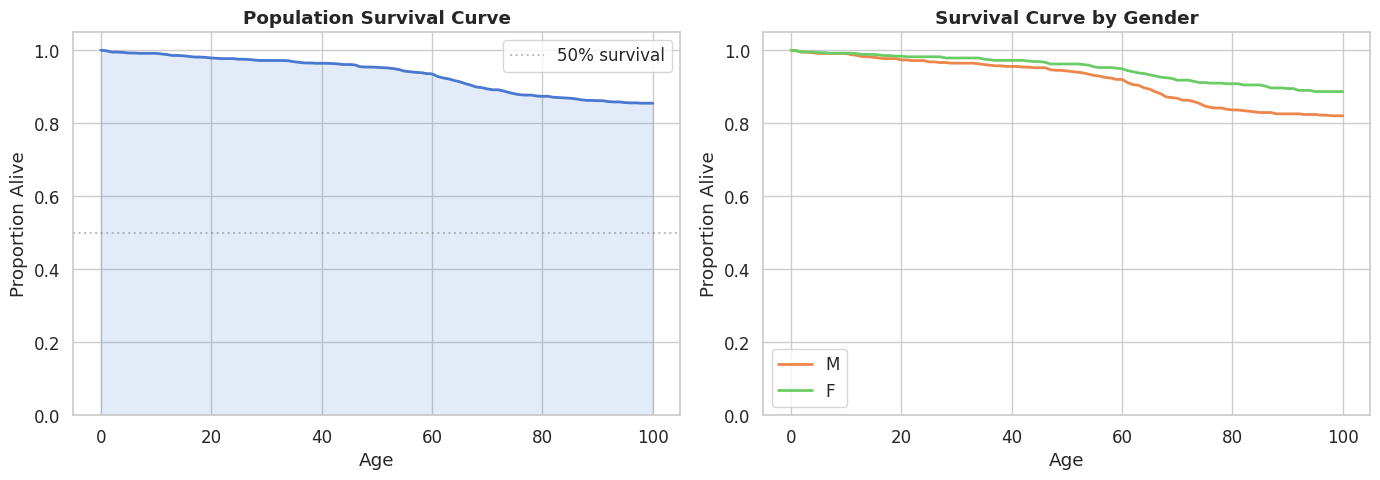

In [5]:
# 2.1 Kaplan-Meier-style survival curve (simplified)
# Calculate age-at-death or censoring age
patients['SURVIVAL_TIME'] = patients['AGE']  # age at death or current age
patients['EVENT'] = (~patients['IS_ALIVE']).astype(int)

# Survival by age
ages = sorted(patients['SURVIVAL_TIME'].unique())
alive_at = []
for age in range(0, 101):
    n_alive = len(patients[(patients['SURVIVAL_TIME'] >= age) | (patients['IS_ALIVE'])])
    alive_at.append({'Age': age, 'Proportion_Alive': n_alive / len(patients)})
survival_df = pd.DataFrame(alive_at)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(survival_df['Age'], survival_df['Proportion_Alive'], color=COLORS[0], linewidth=2)
axes[0].fill_between(survival_df['Age'], survival_df['Proportion_Alive'], alpha=0.15, color=COLORS[0])
axes[0].set_title('Population Survival Curve')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Proportion Alive')
axes[0].set_ylim(0, 1.05)
axes[0].axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='50% survival')
axes[0].legend()

# Survival by gender
for gender, color in [('M', COLORS[1]), ('F', COLORS[2])]:
    subset = patients[patients['GENDER'] == gender]
    alive_g = []
    for age in range(0, 101):
        n = len(subset[(subset['SURVIVAL_TIME'] >= age) | (subset['IS_ALIVE'])])
        alive_g.append({'Age': age, 'Prop': n / len(subset)})
    sg = pd.DataFrame(alive_g)
    axes[1].plot(sg['Age'], sg['Prop'], color=color, linewidth=2, label=f'{gender}')

axes[1].set_title('Survival Curve by Gender')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Proportion Alive')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.savefig('images/29_survival_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# 2.2 Mortality risk factor analysis — chi-square tests
deceased = patients[~patients['IS_ALIVE']]
alive = patients[patients['IS_ALIVE']]

print("=== Mortality Risk Factors (Chi-Square Tests) ===")
cat_vars = ['GENDER', 'RACE', 'ETHNICITY', 'MARITAL']
chi_results = []
for var in cat_vars:
    ct = pd.crosstab(patients[var].fillna('Unknown'), patients['IS_ALIVE'])
    chi2, p, dof, expected = chi2_contingency(ct)
    cramers_v = np.sqrt(chi2 / (len(patients) * (min(ct.shape) - 1)))
    chi_results.append({'Variable': var, 'Chi2': chi2, 'p_value': p, 'Cramers_V': cramers_v,
                        'Significant': 'Yes' if p < 0.05 else 'No'})
    print(f"  {var:<15} Chi²={chi2:>8.2f}  p={p:.4f}  Cramér's V={cramers_v:.3f}  {'*** Significant' if p < 0.05 else ''}")

# Mortality rate by race
print("\n=== Mortality Rate by Race ===")
mort_race = patients.groupby('RACE').agg(
    total=('Id', 'count'),
    deceased=('IS_ALIVE', lambda x: (~x).sum())
).reset_index()
mort_race['mortality_rate'] = (mort_race['deceased'] / mort_race['total'] * 100).round(1)
print(mort_race.to_string(index=False))


=== Mortality Risk Factors (Chi-Square Tests) ===
  GENDER          Chi²=   10.36  p=0.0013  Cramér's V=0.094  *** Significant
  RACE            Chi²=   38.71  p=0.0000  Cramér's V=0.182  *** Significant
  ETHNICITY       Chi²=    1.96  p=0.1610  Cramér's V=0.041  
  MARITAL         Chi²=   20.30  p=0.0000  Cramér's V=0.132  *** Significant

=== Mortality Rate by Race ===
  RACE  total  deceased  mortality_rate
 asian     90        13            14.4
 black    101        23            22.8
native     13         9            69.2
 other      2         0             0.0
 white    965       126            13.1


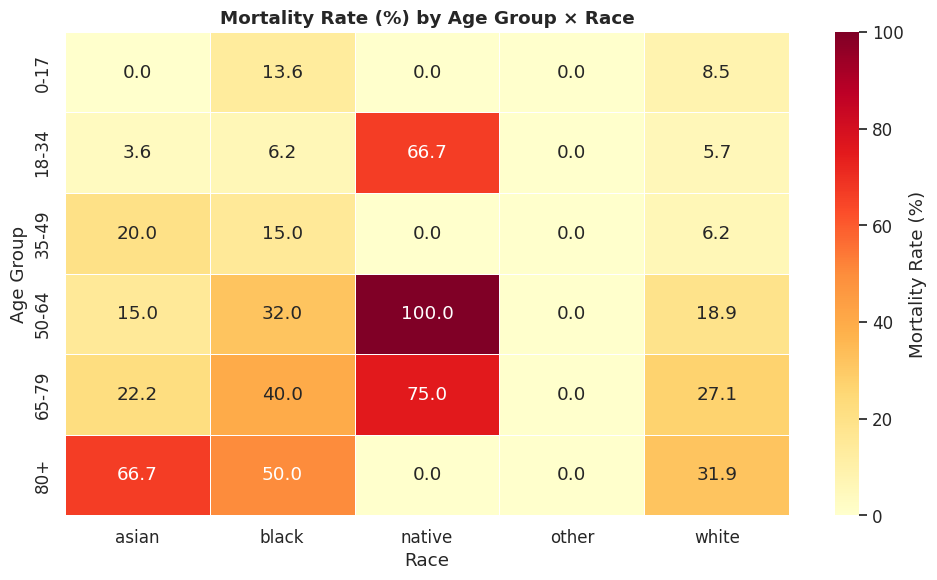

In [7]:
# 2.3 Mortality rate heatmap — Age Group × Race
mort_heatmap = patients.groupby(['AGE_GROUP', 'RACE']).agg(
    total=('Id', 'count'),
    deceased=('IS_ALIVE', lambda x: (~x).sum())
).reset_index()
mort_heatmap['rate'] = (mort_heatmap['deceased'] / mort_heatmap['total'] * 100).round(1)
pivot = mort_heatmap.pivot_table(index='AGE_GROUP', columns='RACE', values='rate', fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Mortality Rate (%)'})
ax.set_title('Mortality Rate (%) by Age Group × Race')
ax.set_ylabel('Age Group')
ax.set_xlabel('Race')
plt.tight_layout()
plt.savefig('images/30_mortality_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Health Equity & Disparity Analysis
Examining disparities across race, ethnicity, and gender in healthcare access, cost, and outcomes.


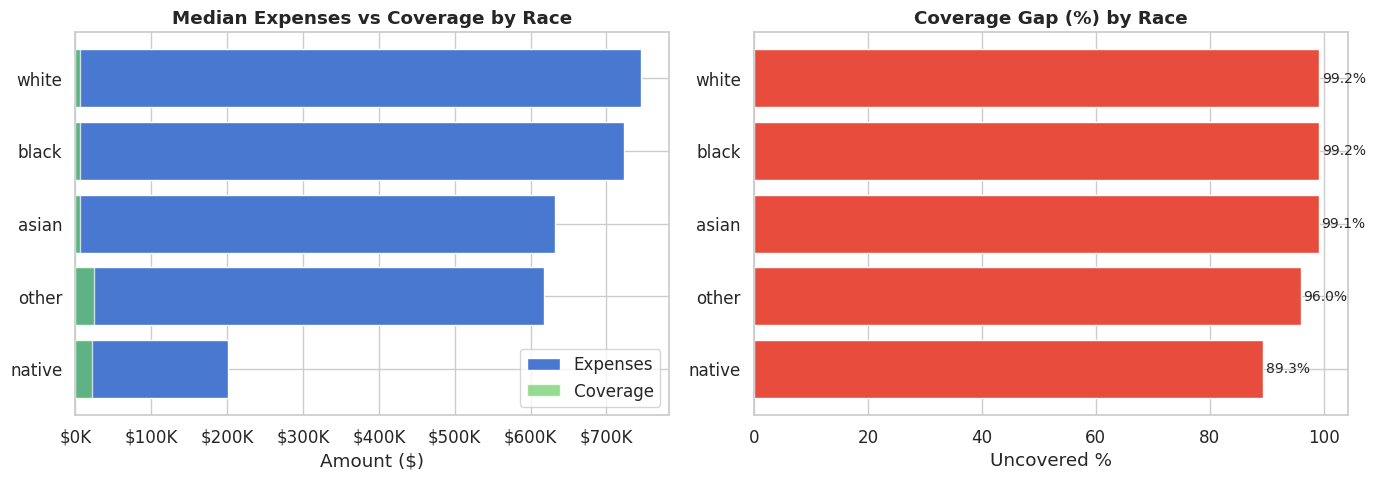

Kruskal-Wallis test for expenses across races: H=11.98, p=0.0175


In [8]:
# 3.1 Healthcare expenses & coverage by race
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

race_expenses = patients.groupby('RACE').agg(
    median_expenses=('HEALTHCARE_EXPENSES', 'median'),
    median_coverage=('HEALTHCARE_COVERAGE', 'median'),
    mean_expenses=('HEALTHCARE_EXPENSES', 'mean'),
    count=('Id', 'count')
).reset_index().sort_values('median_expenses', ascending=True)

axes[0].barh(race_expenses['RACE'], race_expenses['median_expenses'], color=COLORS[0], edgecolor='white', label='Expenses')
axes[0].barh(race_expenses['RACE'], race_expenses['median_coverage'], color=COLORS[2], edgecolor='white', alpha=0.7, label='Coverage')
axes[0].set_title('Median Expenses vs Coverage by Race')
axes[0].set_xlabel('Amount ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[0].legend()

# Coverage gap ratio by race
race_expenses['gap_pct'] = ((race_expenses['median_expenses'] - race_expenses['median_coverage'])
                            / race_expenses['median_expenses'] * 100)
axes[1].barh(race_expenses['RACE'], race_expenses['gap_pct'], color=HIGHLIGHT, edgecolor='white')
axes[1].set_title('Coverage Gap (%) by Race')
axes[1].set_xlabel('Uncovered %')
for i, row in race_expenses.iterrows():
    axes[1].text(row['gap_pct'] + 0.5, list(race_expenses['RACE']).index(row['RACE']),
                 f"{row['gap_pct']:.1f}%", va='center', fontsize=10)

plt.tight_layout()
plt.savefig('images/31_equity_expenses_race.png', dpi=150, bbox_inches='tight')
plt.show()

# Kruskal-Wallis test for expense differences across races
groups = [g['HEALTHCARE_EXPENSES'].values for _, g in patients.groupby('RACE')]
h_stat, p_val = kruskal(*groups)
print(f"Kruskal-Wallis test for expenses across races: H={h_stat:.2f}, p={p_val:.4f}")


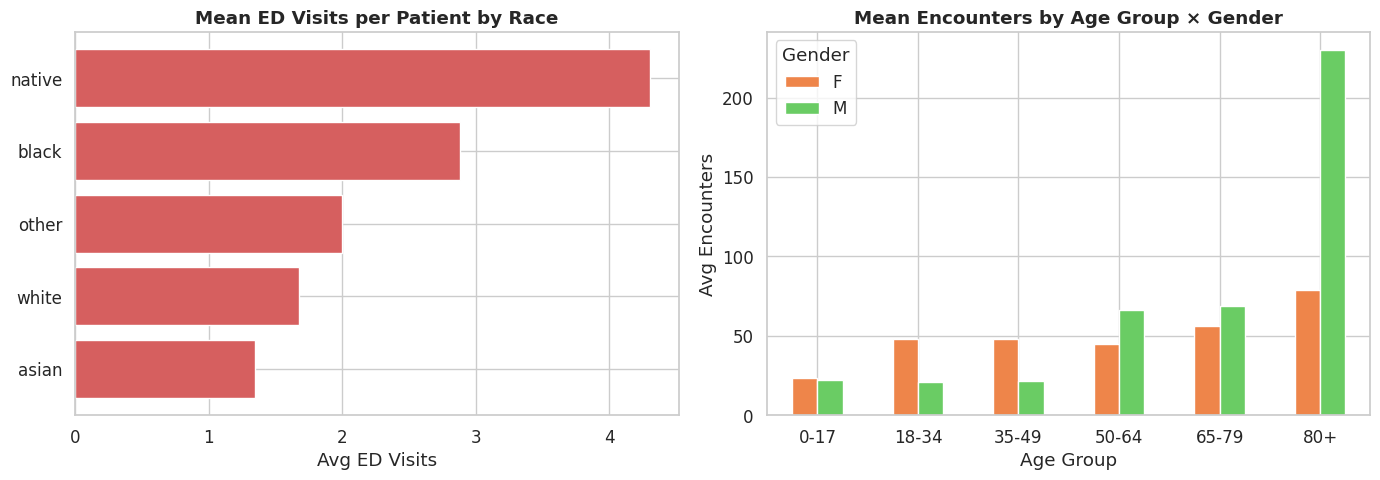

In [9]:
# 3.2 Encounter utilization by demographics
enc_per_patient = encounters.groupby('PATIENT').agg(
    total_encounters=('Id', 'count'),
    ed_visits=('ENCOUNTERCLASS', lambda x: (x == 'emergency').sum()),
    inpatient=('ENCOUNTERCLASS', lambda x: (x == 'inpatient').sum()),
    total_cost=('TOTAL_CLAIM_COST', 'sum')
).reset_index()
demo_util = enc_per_patient.merge(patients[['Id', 'RACE', 'GENDER', 'AGE_GROUP', 'ETHNICITY']],
                                   left_on='PATIENT', right_on='Id')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ED visits by race
ed_race = demo_util.groupby('RACE')['ed_visits'].mean().sort_values()
axes[0].barh(ed_race.index, ed_race.values, color=COLORS[3], edgecolor='white')
axes[0].set_title('Mean ED Visits per Patient by Race')
axes[0].set_xlabel('Avg ED Visits')

# Total encounters by gender × age group
gender_age = demo_util.groupby(['AGE_GROUP', 'GENDER'])['total_encounters'].mean().unstack()
gender_age.plot(kind='bar', ax=axes[1], color=[COLORS[1], COLORS[2]], edgecolor='white')
axes[1].set_title('Mean Encounters by Age Group × Gender')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Avg Encounters')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Gender')

plt.tight_layout()
plt.savefig('images/32_equity_utilization.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# 3.3 Statistical tests for disparities
print("=== Mann-Whitney U Tests: Gender Disparities ===")
for metric in ['total_encounters', 'ed_visits', 'total_cost']:
    male = demo_util[demo_util['GENDER'] == 'M'][metric]
    female = demo_util[demo_util['GENDER'] == 'F'][metric]
    u_stat, p = mannwhitneyu(male, female, alternative='two-sided')
    print(f"  {metric:<20} U={u_stat:>10,.0f}  p={p:.4f}  "
          f"Male median={male.median():>8,.1f}  Female median={female.median():>8,.1f}  "
          f"{'*** Sig' if p < 0.05 else ''}")

print("\n=== Kruskal-Wallis: Race Disparities ===")
for metric in ['total_encounters', 'ed_visits', 'total_cost']:
    groups = [g[metric].values for _, g in demo_util.groupby('RACE')]
    h, p = kruskal(*groups)
    print(f"  {metric:<20} H={h:>8.2f}  p={p:.4f}  {'*** Sig' if p < 0.05 else ''}")


=== Mann-Whitney U Tests: Gender Disparities ===
  total_encounters     U=   122,701  p=0.0000  Male median=    21.0  Female median=    35.0  *** Sig
  ed_visits            U=   145,676  p=0.0000  Male median=     1.0  Female median=     1.0  *** Sig
  total_cost           U=   122,544  p=0.0000  Male median= 2,660.7  Female median= 4,520.6  *** Sig

=== Kruskal-Wallis: Race Disparities ===
  total_encounters     H=   18.26  p=0.0011  *** Sig
  ed_visits            H=   19.58  p=0.0006  *** Sig
  total_cost           H=   18.02  p=0.0012  *** Sig


---
## 4. Geographic Analysis
County-level patient concentration, healthcare resource distribution, and access patterns.


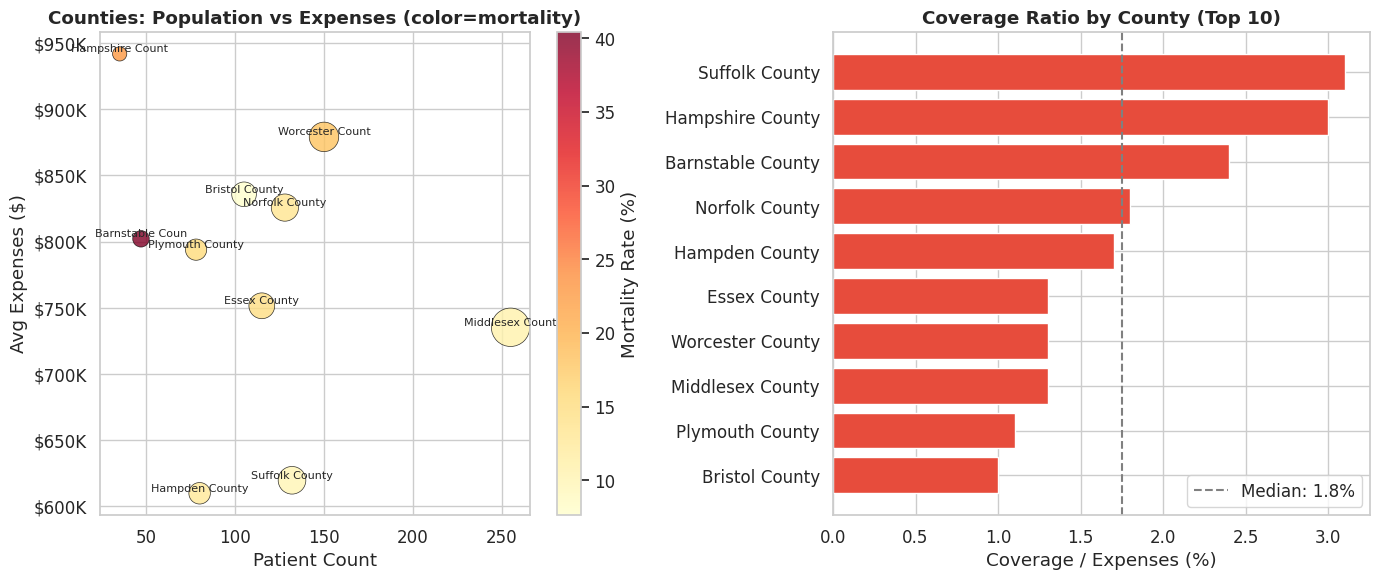

Counties: 14 | Largest: Middlesex County (255 patients)


In [11]:
# 4.1 County-level summary with health metrics
county_summary = patients.groupby('COUNTY').agg(
    patients=('Id', 'count'),
    avg_age=('AGE', 'mean'),
    mortality_rate=('IS_ALIVE', lambda x: (1 - x.mean()) * 100),
    avg_expenses=('HEALTHCARE_EXPENSES', 'mean'),
    avg_coverage=('HEALTHCARE_COVERAGE', 'mean')
).reset_index().sort_values('patients', ascending=False)
county_summary['coverage_ratio'] = (county_summary['avg_coverage'] / county_summary['avg_expenses'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top counties by patient count, colored by mortality rate
top_counties = county_summary.head(10)
scatter = axes[0].scatter(top_counties['patients'], top_counties['avg_expenses'],
                          c=top_counties['mortality_rate'], cmap='YlOrRd',
                          s=top_counties['patients'] * 3, edgecolors='black', linewidth=0.5, alpha=0.8)
for _, row in top_counties.iterrows():
    axes[0].annotate(row['COUNTY'][:15], (row['patients'], row['avg_expenses']),
                     fontsize=8, ha='center', va='bottom')
axes[0].set_title('Counties: Population vs Expenses (color=mortality)')
axes[0].set_xlabel('Patient Count')
axes[0].set_ylabel('Avg Expenses ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
plt.colorbar(scatter, ax=axes[0], label='Mortality Rate (%)')

# Coverage ratio by county
top10 = county_summary.head(10).sort_values('coverage_ratio')
colors = [HIGHLIGHT if v < 5 else COLORS[0] for v in top10['coverage_ratio']]
axes[1].barh(top10['COUNTY'], top10['coverage_ratio'], color=colors, edgecolor='white')
axes[1].set_title('Coverage Ratio by County (Top 10)')
axes[1].set_xlabel('Coverage / Expenses (%)')
axes[1].axvline(county_summary['coverage_ratio'].median(), color='gray', linestyle='--',
                label=f"Median: {county_summary['coverage_ratio'].median():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.savefig('images/33_geographic_health.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Counties: {len(county_summary)} | Largest: {county_summary.iloc[0]['COUNTY']} ({county_summary.iloc[0]['patients']} patients)")


---
## 5. Cohort Comparison — High-Cost vs Low-Cost Patients
Identifying demographic characteristics that differentiate high-cost from low-cost patients.


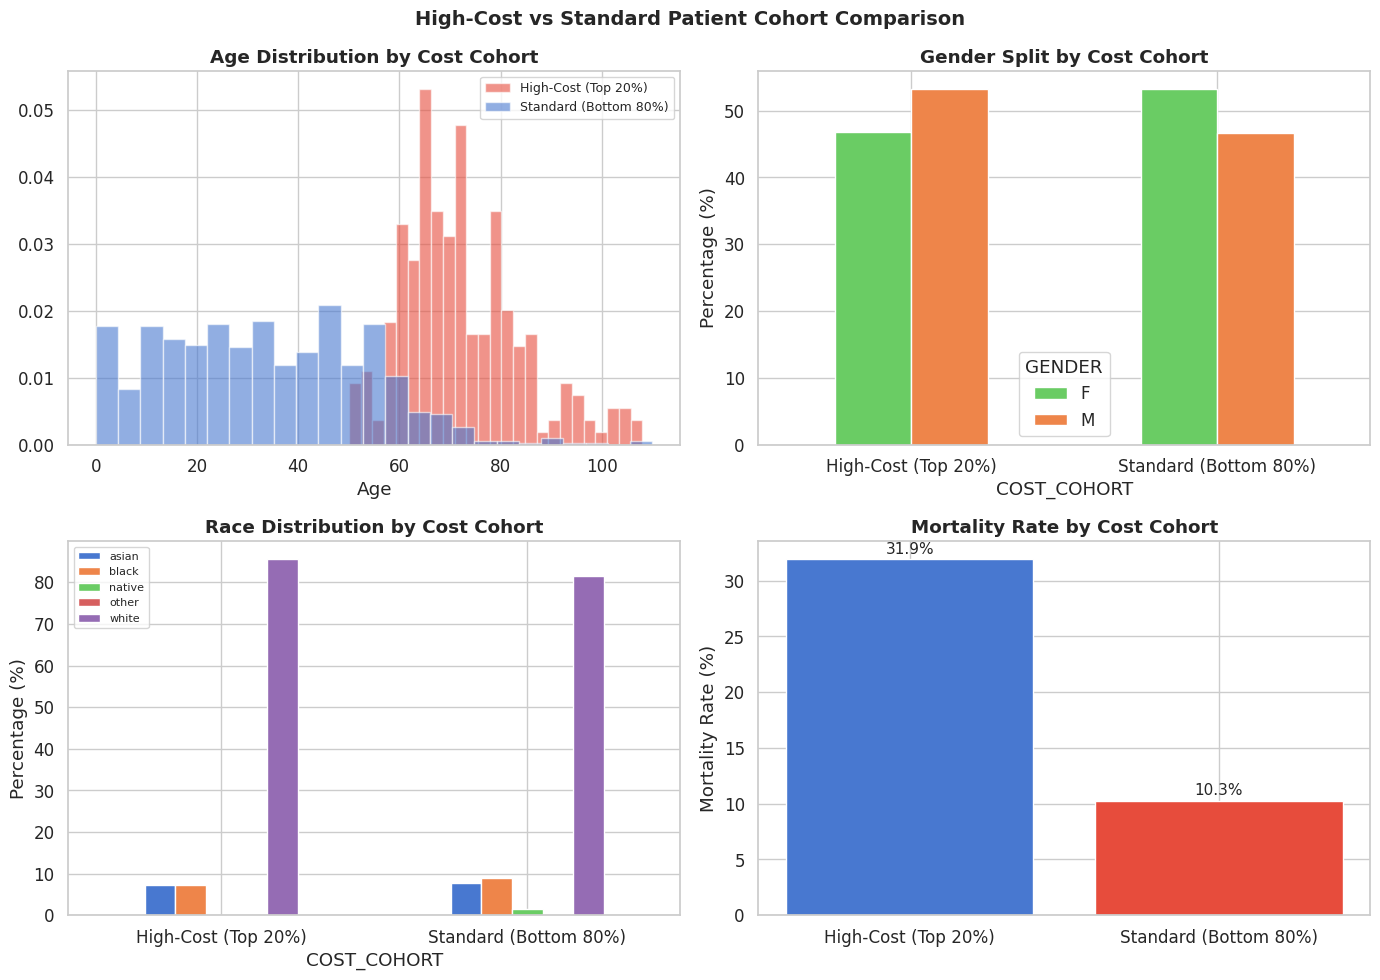

In [12]:
# 5.1 Define cohorts: top 20% vs bottom 80% by expenses
threshold = patients['HEALTHCARE_EXPENSES'].quantile(0.80)
patients['COST_COHORT'] = np.where(patients['HEALTHCARE_EXPENSES'] >= threshold, 'High-Cost (Top 20%)', 'Standard (Bottom 80%)')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
for cohort, color in [('High-Cost (Top 20%)', HIGHLIGHT), ('Standard (Bottom 80%)', COLORS[0])]:
    subset = patients[patients['COST_COHORT'] == cohort]
    axes[0, 0].hist(subset['AGE'], bins=25, alpha=0.6, color=color, label=cohort, edgecolor='white', density=True)
axes[0, 0].set_title('Age Distribution by Cost Cohort')
axes[0, 0].set_xlabel('Age')
axes[0, 0].legend(fontsize=9)

# Gender split
cohort_gender = pd.crosstab(patients['COST_COHORT'], patients['GENDER'], normalize='index') * 100
cohort_gender.plot(kind='bar', ax=axes[0, 1], color=[COLORS[2], COLORS[1]], edgecolor='white')
axes[0, 1].set_title('Gender Split by Cost Cohort')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].tick_params(axis='x', rotation=0)

# Race distribution
cohort_race = pd.crosstab(patients['COST_COHORT'], patients['RACE'], normalize='index') * 100
cohort_race.plot(kind='bar', ax=axes[1, 0], color=COLORS[:5], edgecolor='white')
axes[1, 0].set_title('Race Distribution by Cost Cohort')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].legend(fontsize=8)

# Mortality rate
cohort_mort = patients.groupby('COST_COHORT')['IS_ALIVE'].apply(lambda x: (1-x.mean())*100)
axes[1, 1].bar(cohort_mort.index, cohort_mort.values, color=[COLORS[0], HIGHLIGHT], edgecolor='white')
axes[1, 1].set_title('Mortality Rate by Cost Cohort')
axes[1, 1].set_ylabel('Mortality Rate (%)')
for i, (idx, val) in enumerate(cohort_mort.items()):
    axes[1, 1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=11)

plt.suptitle('High-Cost vs Standard Patient Cohort Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/34_cohort_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# 5.2 Statistical comparison of cohorts
high_cost = patients[patients['COST_COHORT'] == 'High-Cost (Top 20%)']
standard = patients[patients['COST_COHORT'] == 'Standard (Bottom 80%)']

print(f"High-Cost cohort: n={len(high_cost)}, Median age={high_cost['AGE'].median():.0f}")
print(f"Standard cohort:  n={len(standard)}, Median age={standard['AGE'].median():.0f}")

u_stat, p = mannwhitneyu(high_cost['AGE'], standard['AGE'])
print(f"\nMann-Whitney U (Age): U={u_stat:,.0f}, p={p:.4f}")

# Chi-square for categorical differences
for var in ['GENDER', 'RACE']:
    ct = pd.crosstab(patients['COST_COHORT'], patients[var])
    chi2, p, _, _ = chi2_contingency(ct)
    print(f"Chi-square ({var}): χ²={chi2:.2f}, p={p:.4f} {'*** Sig' if p < 0.05 else ''}")


High-Cost cohort: n=235, Median age=70
Standard cohort:  n=936, Median age=33

Mann-Whitney U (Age): U=210,584, p=0.0000
Chi-square (GENDER): χ²=2.93, p=0.0871 
Chi-square (RACE): χ²=4.85, p=0.3028 


---
## 6. Power BI-Ready Exports


In [14]:
# Export demographic summary tables
demo_summary = patients.groupby(['AGE_GROUP', 'GENDER', 'RACE']).agg(
    patient_count=('Id', 'count'),
    avg_age=('AGE', 'mean'),
    mortality_rate=('IS_ALIVE', lambda x: (1-x.mean())*100),
    avg_expenses=('HEALTHCARE_EXPENSES', 'mean'),
    avg_coverage=('HEALTHCARE_COVERAGE', 'mean')
).reset_index().round(2)

demo_summary.to_csv('data/processed/demographics_summary.csv', index=False)
county_summary.to_csv('data/processed/county_health_summary.csv', index=False)
outlier_df.to_csv('data/processed/outlier_detection.csv', index=False)

print(f"Exported:")
print(f"  demographics_summary.csv   ({len(demo_summary)} rows)")
print(f"  county_health_summary.csv  ({len(county_summary)} rows)")
print(f"  outlier_detection.csv      ({len(outlier_df)} rows)")


Exported:
  demographics_summary.csv   (42 rows)
  county_health_summary.csv  (14 rows)
  outlier_detection.csv      (3 rows)
